In [1]:
# Starter code

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
len(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3 # context length

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     
Xdev, Ydev = build_dataset(words[n1:n2])   
Xte,  Yte  = build_dataset(words[n2:])     

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [47]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)*0.2
b1 = torch.randn(n_hidden, generator=g)*0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) *0.01 
b2 = torch.randn(vocab_size, generator=g)*0 # so that b2 is 0 at initialisation
parameters = [C, W1, b1, W2, b2]

print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [48]:
max_steps=200000
batch_size=32
lossi=[]
for i in range (max_steps):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,) ) 
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X ,Y
    # forward pass
    emb = C[Xb] 
    embcat=emb.view(emb.shape[0], -1)
    hpreact= embcat @ W1 +b1 # h pre activation is too far off from 0 creating a tanh that is saturated on the two ends
    h=torch.tanh(hpreact) 
    # gradient of tanh is defined as (1-t**2)*out.grad but if t = 1 or -1 it makes the whole term zero effectively removing the influence of out.grad and making self.grad =0
    logits= h @ W2 + b2
    loss= F.cross_entropy(logits,Yb)
    
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    lr=0.1 if i <100000 else 0.01
    for p in parameters:
        p.data+= -lr*p.grad 
    
    # track stats:
    if i % 1000==0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): 4f}')
   
    lossi.append(loss.log10().item())
    # break
print(loss.item()) 


      0/ 200000:  3.303095
   1000/ 200000:  3.020783
   2000/ 200000:  2.489860
   3000/ 200000:  2.033719
   4000/ 200000:  2.026126
   5000/ 200000:  2.134021
   6000/ 200000:  2.117700
   7000/ 200000:  2.721303
   8000/ 200000:  1.885184
   9000/ 200000:  1.935547
  10000/ 200000:  2.298219
  11000/ 200000:  2.219884
  12000/ 200000:  2.473626
  13000/ 200000:  2.488918
  14000/ 200000:  2.253781
  15000/ 200000:  1.903257
  16000/ 200000:  2.105403
  17000/ 200000:  2.177584
  18000/ 200000:  2.330413
  19000/ 200000:  2.401407
  20000/ 200000:  2.080763
  21000/ 200000:  2.540335
  22000/ 200000:  2.038131
  23000/ 200000:  2.168004
  24000/ 200000:  2.030015
  25000/ 200000:  2.142458
  26000/ 200000:  2.226798
  27000/ 200000:  2.316431
  28000/ 200000:  2.094631
  29000/ 200000:  1.924407
  30000/ 200000:  1.823408
  31000/ 200000:  2.522916
  32000/ 200000:  2.407739
  33000/ 200000:  1.774689
  34000/ 200000:  2.727889
  35000/ 200000:  2.368925
  36000/ 200000:  2.062417
 

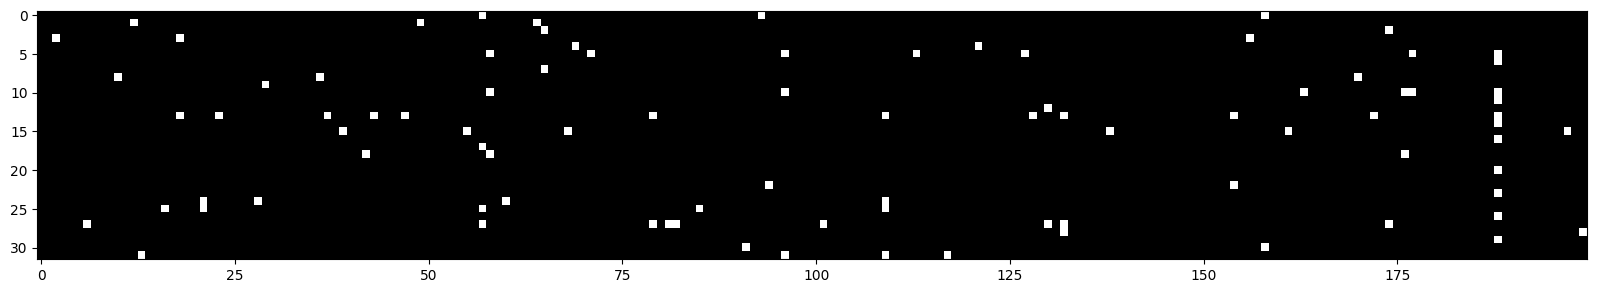

In [42]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs()> 0.99, cmap='gray',interpolation='nearest') #white if true
# no columns of complete white which means there are no dead neurons
# the problem with too many neurons in that range is that they lie in the inactive part of tanh function this will happen in any function with flat parts relu or sigmoid

In [43]:
h.view(-1).shape

torch.Size([6400])

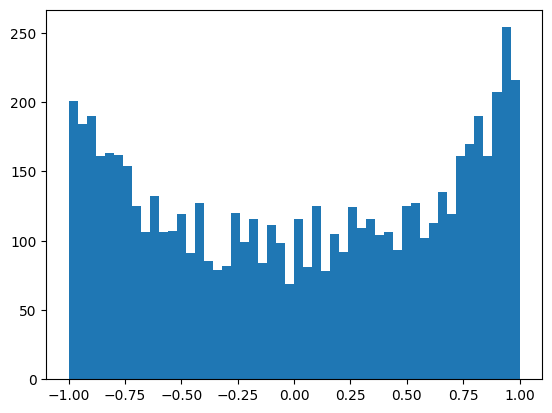

In [ ]:
plt.hist(h.view(-1).tolist(),50); # ; for just the graph without excess information
# after multiplying W1 with 0.2 and b1 with 0.01 we have much better graph

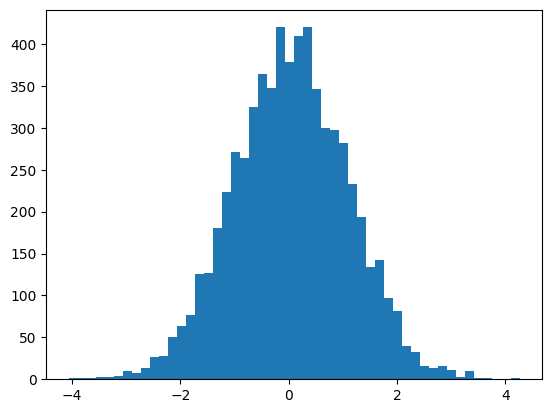

In [45]:
plt.hist(hpreact.view(-1).tolist(),50);

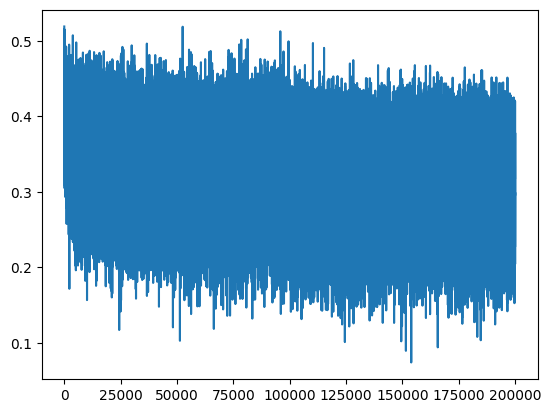

In [49]:
plt.plot(lossi)
# not hockey stick shape anymore because there the optimisation first compresses the logits and then rearrage it. We took away the first part
# this is true for all neural nets

In [ ]:
logits[0] # much closer to 0

tensor([ 0.0653, -0.0905, -0.0347,  0.2435,  0.2300,  0.0670, -0.0576,  0.2666,
         0.1166,  0.0025, -0.0285,  0.1094,  0.1798, -0.3613,  0.1176,  0.1426,
        -0.0253, -0.0043, -0.0430, -0.1340,  0.1443,  0.0068, -0.0070, -0.1873,
         0.0948, -0.0153,  0.0791], grad_fn=<SelectBackward0>)

In [ ]:
# we expect the initial loss to be the negative log probability where all the characters are equally likely
-torch.tensor(1/27.0).log() # this is expected initial loss

tensor(3.2958)

In [50]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 +b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
# better loss after the initialising properly because we spend more iterations making the neural net better than compression

train 2.036710739135742
val 2.105074644088745


In [9]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khi.
milia.
aty.
skanden.
jazhuen.
delynn.
jageric.
eline.
tccei.
vin.
leigh.
ham.
join.
quint.
sulin.
alianni.
wazelo.
dearynix.
